# Fish Passage Barrier Prioritization

## Objective
The purpose of this notebook is to generate a prioritized list of fish passage barriers.

## Data Sources
- Output generated from `FPB_attributes.ipynb` which provides asset coordinates, stream type, subbasin names, and stream names.
- Output from the `Fish Passage Barriers` custom geoprocessing tool created by the consultant team which provides counts of upstream and downstream barriers and potential habitat gain.
- `Prioritization Scoring Input Data.xlsx` from the culvert assessement priorization which links our assets to WDFW barriers and provides barrier status. It would be better if these data could be automated, but at present this will need to be mannually updated.
- `StreamSubasinTierAndManagementStrategies.xlsx` - a table that provides the subbasin managment strategies from the Watershed Management Plan and stream tiers from the Environmental Monitoring Program.

In [1]:
# Install the necessary packages
from datetime import datetime
from IPython.display import display, Markdown
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(rc = {'figure.figsize': (8, 5)})

# Set the option to display all columns in a pd dataframe
pd.set_option('display.max_columns', None)

# Set the seaborn theme
sns.set_style("white")

todays_date = str(datetime.now().date())
display(Markdown(f'**Notebook created:** 2025-02-15'))
display(Markdown(f'**Notebook last updated:** {todays_date}'))

**Notebook created:** 2025-02-15

**Notebook last updated:** 2025-11-08

### Known Issues

- There are 6 assets in the consultant's input data that are not in our culvert or gravity main layers so some info is missing for those. They are: '360400', 'PARKS-1', 'PARKS-2', 'PARKS-3', 'PARKS-4', 'PARKS-5'
- Note, the 360400 asset is not in our gravity main layer but its location pairs with a privately owned GM on Kelsey at 138th Ave NE. We no longer have an asset number listed for that pipe but that row in the GM layer was last updated on 5/28/24 so it's very likely it formerly had that number and that's how the consultants accordingly identified it.
- I have some doubts about the quality of the input data from the consultants. Barriers may not be accurately classified and/or linked to WDFW sites, but it is going to take a while to track down those issues and verify. So for now I am moving ahead with the methodology and will make refinements later.
- The upstream channel length computed from the consultant's tool appears to be wildly inaccurate. I'll need to fix this.

### Notes for Future Improvements

- The trace output currently doesn't specify the status of the next upstream barrier. That information would be nice to have but can be extracted using regular expressions. Also, I've realized that the upstream tallies are just to the next complete barrier so all the partial and unknown barriers tallied are passed through on the way to the next complete barrier.
- The trace output does not differentiate between 1/3 and 2/3 partial barriers when tallying downstream/upstream barriers. That level of specificity would also be nice.

## Process

### Read in the data

In [2]:
# Subbasin managment strategies and tier prioritization
strategies = pd.read_excel(r"V:\UtilitiesDeptGIS\ArcGIS\Watershed Planning Team\Environmental Monitoring\Fish Passage Barriers\Fish Passage Barriers\Data\StreamSubasinTierAndManagementStrategies.xlsx")
strategies.drop(columns = ['Stream', 'MS score', 'EMP score'], inplace = True)   # Remove the Stream name column since the scores are really by subbasin and the asset attributes will give the finer-grained stream name
strategies.rename(columns = {'Composite Score': 'Subbasin Priority Score'}, inplace = True)

# Convert all object columns to pandas StringDtype
strategies = strategies.astype({
    col: "string" for col in strategies.select_dtypes(include="object").columns
})

strategies

,Subbasin,Subbasin Management Strategy,EMP Stream Tier,Subbasin Priority Score
0,Lewis Creek,Protect,Tier 1,9.00
1,Coal Creek,Protect/Improve,Tier 1,7.50
2,Kelsey Creek,Improve,Tier 1,6.00
3,Mercer Slough,Improve,Tier 1,6.00
4,Valley Creek,Protect/Improve,Tier 2,5.00
5,Newport Creek,Improve,Tier 2,4.00
6,Richards Creek,Improve,Tier 2,4.00
7,West Tributary,Improve,Tier 2,4.00
8,Vasa Creek Area,Improve,Tier 2,4.00
9,Yarrow Creek,Improve,Tier 2,4.00


In [3]:
# Check the data types
strategies.dtypes

Subbasin                        string[python]
Subbasin Management Strategy    string[python]
EMP Stream Tier                 string[python]
Subbasin Priority Score                float64
dtype: object

In [4]:
# Output from the custom geoprocessing tool
trace = pd.read_csv(r"V:\UtilitiesDeptGIS\Asset Management\Storm\Culvert and Barrier ID Automation Tool\4_PrioritizationFiles\OutputFile\TraceResult.csv")
trace.rename(columns = {'Structure ID' : 'FACILITYID'}, inplace = True)

# Convert all object columns to pandas StringDtype
trace = trace.astype({
    col: "string" for col in trace.select_dtypes(include="object").columns
})

print("There are", trace.shape[0], "rows in the data frame.")
trace.head()

There are 346 rows in the data frame.


,FACILITYID,Structure Type,Upstream Channel Length,# Upstream Barriers,Upsteam Full Barrier,Upstream Partial Barrier,Upstream No Barrier,Upstream Natural Barrier,Upstream Unknown Barrier,Upstream Barriers,# Downstream Barriers,Downstream Full Barrier,Downstream Partial Barrier,Downstream No Barrier,Downstream Natural Barrier,Downstream Unknown Barrier,Downstream Barriers
0,353780,Gravity Main,602.300000,0,0,0,0,0,0,<NA>,19,1,4,9,0,5,922157 (Unknown Barrier) -> 921607 (Partial Ba...
1,351811,Gravity Main,0.000000,0,0,0,0,0,0,<NA>,0,0,0,0,0,0,<NA>
2,351793,Gravity Main,0.000000,0,0,0,0,0,0,<NA>,0,0,0,0,0,0,<NA>
3,354218,Gravity Main,11609.289534,6,0,1,2,0,3,922147 (Unknown Barrier) -> 922151 (Unknown Ba...,13,1,3,7,0,2,922146 (Partial Barrier) -> 922397 (No Barrier...
4,337694,Gravity Main,1449.500000,0,0,0,0,0,0,<NA>,12,1,3,7,0,1,930615 (Partial Barrier) -> 930616 (Partial Ba...


In [5]:
# Get the data types
trace.dtypes

FACILITYID                    string[python]
Structure Type                string[python]
Upstream Channel Length              float64
# Upstream Barriers                    int64
Upsteam Full Barrier                   int64
Upstream Partial Barrier               int64
Upstream No Barrier                    int64
Upstream Natural Barrier               int64
Upstream Unknown Barrier               int64
Upstream Barriers             string[python]
# Downstream Barriers                  int64
Downstream Full Barrier                int64
Downstream Partial Barrier             int64
Downstream No Barrier                  int64
Downstream Natural Barrier             int64
Downstream Unknown Barrier             int64
Downstream Barriers           string[python]
dtype: object

In [6]:
# Fix a typo in the trace output
trace = trace.rename(columns={'Upsteam Full Barrier': 'Upstream Full Barrier'})

In [7]:
# Check for duplicated assets
trace['FACILITYID'][trace['FACILITYID'].duplicated()]

Series([], Name: FACILITYID, dtype: string)

Good. No duplicates.

In [8]:
# Table that links the assets with the WDFW barrier ID (from the culvert condition assessment)
culv_input = pd.read_excel(r"V:\UtilitiesDeptGIS\Asset Management\Storm\Culvert and Barrier ID Automation Tool\4_PrioritizationFiles\Prioritization Scoring Input Data.xlsx", sheet_name=0)
gm_input = pd.read_excel(r"V:\UtilitiesDeptGIS\Asset Management\Storm\Culvert and Barrier ID Automation Tool\4_PrioritizationFiles\Prioritization Scoring Input Data.xlsx", sheet_name=1)
barrier_input = pd.concat([culv_input, gm_input])
barrier_input.rename(columns = {'WDFW\nSite ID': 'WDFW Site ID',
                               'Fish Pass': 'Fish Passability'}, inplace=True)
barrier_input = barrier_input[['FACILITYID', 'WDFW Site ID', 'Barrier Site ID', 'Barrier Class',
       'Fish Passability']] # keep only the necessary columns

# Convert all object columns to pandas StringDtype
barrier_input = barrier_input.astype({
    col: "string" for col in barrier_input.select_dtypes(include="object").columns
})

print("There are", barrier_input.shape[0], "rows in the data frame.")
barrier_input.head()

There are 346 rows in the data frame.


,FACILITYID,WDFW Site ID,Barrier Site ID,Barrier Class,Fish Passability
0,463954,922165,922165,Partial Barrier,33
1,539989,996964,996964,Full Barrier,0
2,340855,922415,922415,Unknown Barrier,Unknown
3,340862,922415,922415,Unknown Barrier,Unknown
4,340870,922415,922415,Unknown Barrier,Unknown


In [9]:
# Get the data types
barrier_input.dtypes

FACILITYID          string[python]
WDFW Site ID        string[python]
Barrier Site ID     string[python]
Barrier Class       string[python]
Fish Passability    string[python]
dtype: object

In [10]:
# Check for duplicated assets
barrier_input['FACILITYID'][barrier_input['FACILITYID'].duplicated()]

Series([], Name: FACILITYID, dtype: string)

Good. No duplicates.

In [11]:
# Culvert and gravity main attributes (assembled in the FPB_attributes.ipynb)
asset_attribs = pd.read_csv(r"V:\UtilitiesDeptGIS\ArcGIS\Watershed Planning Team\Environmental Monitoring\Fish Passage Barriers\Fish Passage Barriers\Output\AssetsByBasinStreamAndType.csv")
asset_attribs = asset_attribs.drop(columns = ['OID_', 'SDPIPE'])
asset_attribs['BASIN'] = asset_attribs['BASIN'].str.title()
asset_attribs['NAME'] = asset_attribs['NAME'].str.title()
asset_attribs.rename(columns = {'BASIN' : 'Subbasin',
                               'NAME' : 'Stream',
                               'TYPE' : 'Stream Type'}, inplace = True)

# Convert all object columns to pandas StringDtype
asset_attribs = asset_attribs.astype({
    col: "string" for col in asset_attribs.select_dtypes(include="object").columns
})

# Keep only those assets that are in our barrier list
asset_attribs = asset_attribs[asset_attribs['FACILITYID'].isin(barrier_input['FACILITYID'])] # keep only those assets that are in our barrier list
print("There are", asset_attribs.shape[0], "rows in the data frame.")
asset_attribs.head()

There are 341 rows in the data frame.


,FACILITYID,Subbasin,Longitude,Latitude,Stream,SEGMENTID,Stream Type
533,336595,Coal Creek,-122.130486,47.543372,<NA>,84_10_12_52,N
1072,341900,Lakehurst,-122.185399,47.545417,Lakehurst Creek,86_03,F
1098,339210,Lakehurst,-122.185555,47.545478,<NA>,<NA>,<NA>
1099,339210,Lakehurst,-122.185555,47.545478,<NA>,<NA>,<NA>
1153,339177,Lakehurst,-122.185673,47.545670,<NA>,<NA>,<NA>


In [12]:
# Check for duplicated assets
asset_attribs['FACILITYID'][asset_attribs['FACILITYID'].duplicated()]

1099    339210
Name: FACILITYID, dtype: string

Hmmmm, one duplicated asset. Looks like it is simply a duplicated segment. I've notified UT GIS. Not a problem for this work.

In [13]:
# Drop the second instance of that duplicate
asset_attribs = asset_attribs.drop_duplicates(subset=['FACILITYID'])

In [14]:
# Get the data types
asset_attribs.dtypes

FACILITYID     string[python]
Subbasin       string[python]
Longitude             float64
Latitude              float64
Stream         string[python]
SEGMENTID      string[python]
Stream Type    string[python]
dtype: object

In [15]:
# Get a list of the assets that are in the input list but somehow not in our asset_attribs list

set1 = set(barrier_input['FACILITYID'].tolist())
set2 = set(asset_attribs['FACILITYID'].tolist())

notinassetattribs = set1.difference(set2)
notinassetattribs

{'360400', 'PARKS-1', 'PARKS-2', 'PARKS-3', 'PARKS-4', 'PARKS-5'}

Okay, we are seeing 341 assets here instead of 346 because there are 5 culverts in the inventory with asset #s PARKS-1 through -5 and 360400 which don't exist in our database. Will need to sort out how to deal with them later.

Next, take a look at the subbasin names and adjust as needed.

In [16]:
asset_attribs['Subbasin'].unique().tolist()

['Coal Creek',
 'Lakehurst',
 'Lewis Creek',
 'Vasa Creek',
 'South Sammamish',
 'Sunset Creek',
 'Richards Creek',
 'Meydenbauer Creek',
 'Wilkins Creek',
 'West Tributary',
 'Sturtevant Creek',
 'Kelsey Creek',
 'Goff Creek',
 'Redmond 400',
 'Sears Creek',
 'Valley Creek',
 'Yarrow Creek',
 'Newport',
 'Spirit Ridge',
 'Phantom Creek',
 'North Sammamish',
 'Mercer Slough',
 'Ardmore']

In [17]:
strategies['Subbasin'].unique().tolist()

['Lewis Creek',
 'Coal Creek',
 'Kelsey Creek',
 'Mercer Slough',
 'Valley Creek',
 'Newport Creek',
 'Richards Creek',
 'West Tributary',
 'Vasa Creek Area',
 'Yarrow Creek',
 'Goff Creek',
 'Sunset Creek',
 'Ardmore Area',
 'Phantom Creek',
 'Meydenbauer Creek',
 'Sears Creek',
 'Sturtevant Creek',
 'Lakehurst Area',
 'South Sammamish Area',
 'North Sammamish Area',
 'Redmond 400 Area',
 'Rosemont Area',
 'Spirit Ridge Area',
 'Wilkins Creek',
 'Beaux Arts Area',
 'Clyde Beach Area',
 'Point Cities Area']

Note that some of the subasin names in the `asset_attribs` df are not quite the same as those in the `strategies` df. I'll need to adjust that so that they join properly.

In [18]:
# Adjust subbasin names
asset_attribs.loc[asset_attribs['Subbasin'] == "Ardmore", ['Subbasin']] = "Ardmore Area"
asset_attribs.loc[asset_attribs['Subbasin'] == "Vasa Creek", ['Subbasin']] = "Vasa Creek Area"
asset_attribs.loc[asset_attribs['Subbasin'] == "Lakehurst", ['Subbasin']] = "Lakehurst Area"
asset_attribs.loc[asset_attribs['Subbasin'] == "Newport", ['Subbasin']] = "Newport Creek"
asset_attribs.loc[asset_attribs['Subbasin'] == "South Sammamish", ['Subbasin']] = "South Sammamish Area"
asset_attribs.loc[asset_attribs['Subbasin'] == "North Sammamish", ['Subbasin']] = "North Sammamish Area"
asset_attribs.loc[asset_attribs['Subbasin'] == "Redmond 400", ['Subbasin']] = "Redmond 400 Area"
asset_attribs.loc[asset_attribs['Subbasin'] == "Rosemont", ['Subbasin']] = "Rosemont Area"
asset_attribs.loc[asset_attribs['Subbasin'] == "Spirit Ridge", ['Subbasin']] = "Spirit Ridge Area"
asset_attribs.loc[asset_attribs['Subbasin'] == "Beaux Arts", ['Subbasin']] = "Beaux Arts Area"
asset_attribs.loc[asset_attribs['Subbasin'] == "Clyde Beach", ['Subbasin']] = "Clyde Beach Area"
asset_attribs.loc[asset_attribs['Subbasin'] == "Point Cities", ['Subbasin']] = "Point Cities Area"

asset_attribs['Subbasin'].unique().tolist()

['Coal Creek',
 'Lakehurst Area',
 'Lewis Creek',
 'Vasa Creek Area',
 'South Sammamish Area',
 'Sunset Creek',
 'Richards Creek',
 'Meydenbauer Creek',
 'Wilkins Creek',
 'West Tributary',
 'Sturtevant Creek',
 'Kelsey Creek',
 'Goff Creek',
 'Redmond 400 Area',
 'Sears Creek',
 'Valley Creek',
 'Yarrow Creek',
 'Newport Creek',
 'Spirit Ridge Area',
 'Phantom Creek',
 'North Sammamish Area',
 'Mercer Slough',
 'Ardmore Area']

### Join the datasets

The input spreadsheet generated by the consultants is the base. All other dataframes will be left joined to that table based on the asset number or subbasin name.

In [19]:
barrier_input.shape

(346, 5)

In [20]:
df = pd.merge(barrier_input, asset_attribs, on='FACILITYID', how='left')
df = pd.merge(df, strategies, on='Subbasin', how='left')
df = pd.merge(df, trace, on='FACILITYID', how='left')

print("There are", df.shape[0], "rows in the data frame.")
df.head()

There are 346 rows in the data frame.


,FACILITYID,WDFW Site ID,Barrier Site ID,Barrier Class,Fish Passability,Subbasin,Longitude,Latitude,Stream,SEGMENTID,Stream Type,Subbasin Management Strategy,EMP Stream Tier,Subbasin Priority Score,Structure Type,Upstream Channel Length,# Upstream Barriers,Upstream Full Barrier,Upstream Partial Barrier,Upstream No Barrier,Upstream Natural Barrier,Upstream Unknown Barrier,Upstream Barriers,# Downstream Barriers,Downstream Full Barrier,Downstream Partial Barrier,Downstream No Barrier,Downstream Natural Barrier,Downstream Unknown Barrier,Downstream Barriers
0,463954,922165,922165,Partial Barrier,33,Lewis Creek,-122.104882,47.552229,Lewis Creek Trib 0162D,95_04_65,Ns,Protect,Tier 1,9.00,Culvert,780.410727,1,1,0,0,0,0,922168 (Full Barrier),2,0,0,0,2,0,SB16 (Natural Barrier) -> SB17 (Natural Barrier)
1,539989,996964,996964,Full Barrier,0,South Sammamish Area,-122.112194,47.571904,Sammamish Trib 0161,94_12,F,Improve/Sustain,<NA>,0.75,Culvert,603.610419,1,1,0,0,0,0,996479 (Full Barrier),2,1,0,0,0,1,996969 (Full Barrier) -> 922238 (Unknown Barrier)
2,340855,922415,922415,Unknown Barrier,Unknown,Kelsey Creek,-122.137164,47.602446,Kelsey Creek,76_13,F,Improve,Tier 1,6.00,Culvert,74.375453,1,1,0,0,0,0,922423 (Full Barrier),18,3,3,7,0,5,922416 (No Barrier) -> 922408 (Full Barrier) -...
3,340862,922415,922415,Unknown Barrier,Unknown,Kelsey Creek,-122.137135,47.602461,Kelsey Creek,76_13,F,Improve,Tier 1,6.00,Culvert,74.375453,1,1,0,0,0,0,922423 (Full Barrier),18,3,3,7,0,5,922416 (No Barrier) -> 922408 (Full Barrier) -...
4,340870,922415,922415,Unknown Barrier,Unknown,Kelsey Creek,-122.137145,47.602450,Kelsey Creek,76_13,F,Improve,Tier 1,6.00,Culvert,74.375453,1,1,0,0,0,0,922423 (Full Barrier),18,3,3,7,0,5,922416 (No Barrier) -> 922408 (Full Barrier) -...


### Explore the Data

In [21]:
df.describe()

,Longitude,Latitude,Subbasin Priority Score,Upstream Channel Length,# Upstream Barriers,Upstream Full Barrier,Upstream Partial Barrier,Upstream No Barrier,Upstream Natural Barrier,Upstream Unknown Barrier,# Downstream Barriers,Downstream Full Barrier,Downstream Partial Barrier,Downstream No Barrier,Downstream Natural Barrier,Downstream Unknown Barrier
count,340.000000,340.000000,340.000000,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000,346.000000
mean,-122.153386,47.594316,4.314706,2416.236447,1.355491,0.286127,0.312139,0.320809,0.023121,0.413295,7.184971,1.086705,1.656069,3.343931,0.179191,0.919075
std,0.030001,0.031490,2.567138,3650.360180,2.113637,0.452604,0.738759,0.880366,0.150507,0.871279,6.148916,1.765531,1.756208,3.235703,0.484215,1.196291
min,-122.207152,47.535078,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-122.176111,47.565022,2.000000,357.252684,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,-122.154853,47.602533,4.000000,1049.526594,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,6.500000,1.000000,1.000000,3.000000,0.000000,1.000000
75%,-122.129081,47.623068,6.000000,2283.673283,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,13.000000,1.000000,3.000000,7.000000,0.000000,1.000000
max,-122.099560,47.655800,9.000000,20840.049598,12.000000,1.000000,4.000000,7.000000,1.000000,3.000000,26.000000,15.000000,10.000000,11.000000,2.000000,7.000000


In [22]:
df.describe(include = 'string')

,FACILITYID,WDFW Site ID,Barrier Site ID,Barrier Class,Fish Passability,Subbasin,Stream,SEGMENTID,Stream Type,Subbasin Management Strategy,EMP Stream Tier,Structure Type,Upstream Barriers,Downstream Barriers
count,346,162,179,161,248,340,278,285,297,340,311,346,173,288
unique,346,116,120,4,5,23,57,156,5,5,3,2,98,129
top,463954,922413,936041.0,Full Barrier,0,Kelsey Creek,Kelsey Creek,80_05,F,Improve,Tier 1,Culvert,922147 (Unknown Barrier) -> 922151 (Unknown Ba...,922146 (Partial Barrier) -> 922397 (No Barrier...
freq,1,4,7,52,139,60,25,8,186,191,123,205,10,15


Interesting, although we have 346 unique assets, it appears we have fewer entries for many of the columns. I need to look into that. I suspect that that's because we are currently including non barriers and type N streams.

In [23]:
df.columns

Index(['FACILITYID', 'WDFW Site ID', 'Barrier Site ID', 'Barrier Class',
       'Fish Passability', 'Subbasin', 'Longitude', 'Latitude', 'Stream',
       'SEGMENTID', 'Stream Type', 'Subbasin Management Strategy',
       'EMP Stream Tier', 'Subbasin Priority Score', 'Structure Type',
       'Upstream Channel Length', '# Upstream Barriers',
       'Upstream Full Barrier', 'Upstream Partial Barrier',
       'Upstream No Barrier', 'Upstream Natural Barrier',
       'Upstream Unknown Barrier', 'Upstream Barriers',
       '# Downstream Barriers', 'Downstream Full Barrier',
       'Downstream Partial Barrier', 'Downstream No Barrier',
       'Downstream Natural Barrier', 'Downstream Unknown Barrier',
       'Downstream Barriers'],
      dtype='object')

In [24]:
# Get number of barriers by stream type and barrier type
#df.groupby(['Stream Type', 'Barrier Class',]).agg(Barrier_count = ('Barrier Site ID', 'count'))
pd.crosstab(index = df['Barrier Class'],
            columns = df['Stream Type'])

Stream Type,F,N,Not Typed,Np,Ns
Barrier Class,,,,,
Full Barrier,29,12,5,0,2
No Barrier,26,0,1,0,0
Partial Barrier,27,0,0,1,1
Unknown Barrier,40,1,0,2,2


We see that at present we have a lot of entries that aren't actually barriers or are not on fish-bearing streams. This will be removed for the prioritization.

In [25]:
# Get number of barriers by type and subbasin
#df.groupby(['Subbasin', 'Barrier Class',]).agg(Barrier_count = ('Barrier Site ID', 'count'))
pd.crosstab(index = df['Subbasin'],
            columns = df['Barrier Class'])

Barrier Class,Full Barrier,No Barrier,Partial Barrier,Unknown Barrier
Subbasin,,,,
Ardmore Area,0,0,0,1
Coal Creek,10,4,1,2
Goff Creek,4,0,3,0
Kelsey Creek,4,2,8,16
Lakehurst Area,9,0,0,0
Lewis Creek,1,1,1,3
Mercer Slough,0,1,0,0
Meydenbauer Creek,0,0,1,2
Phantom Creek,0,0,0,2


In [26]:
# Get number of barriers by stream type and subbasin
pd.crosstab(index = df['Subbasin'],
            columns = df['Stream Type'])

Stream Type,F,N,Not Typed,Np,Ns
Subbasin,,,,,
Ardmore Area,0,0,0,1,0
Coal Creek,9,16,2,1,0
Goff Creek,6,0,0,0,0
Kelsey Creek,38,0,6,0,0
Lakehurst Area,5,7,3,0,3
Lewis Creek,5,2,2,7,14
Mercer Slough,1,0,0,0,0
Meydenbauer Creek,8,7,0,0,0
Newport Creek,0,2,1,0,0


#### Remove Non-Barriers and Those on Non-Fish Streams
The above dataframe includes structures that were evaluated by WDFW and determined to not be a barrier. So we need to remove those entries. Also, we have "fish passage barriers" identified on non-fish-bearing streams. Those should be removed as well.

In [27]:
# Remove non-barriers
df = df[df['Barrier Class'] != "No Barrier"]
print("There are now", df.shape[0], "rows in the data frame.")

There are now 132 rows in the data frame.


In [28]:
# Keep only barriers that are on fish bearing streams
df = df[df['Stream Type'] == "F"]
print("There are now", df.shape[0], "rows in the data frame.")

There are now 96 rows in the data frame.


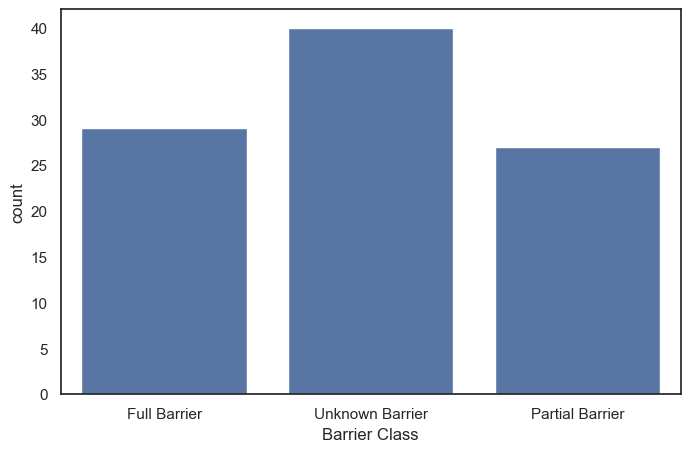

In [29]:
sns.countplot(x='Barrier Class', data=df);

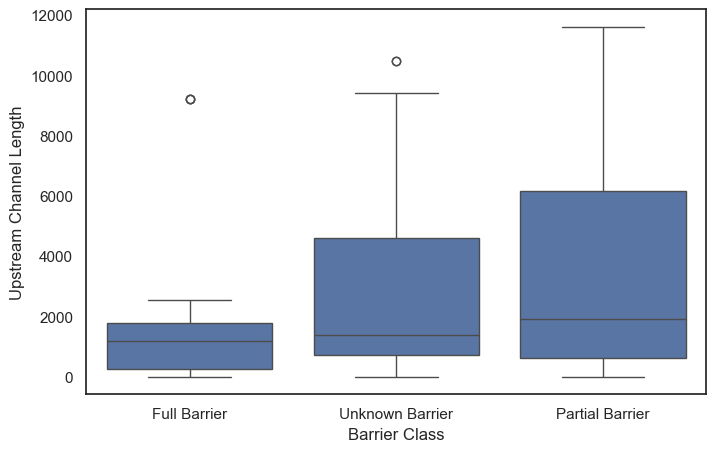

In [30]:
sns.boxplot(x='Barrier Class', y='Upstream Channel Length', data = df);

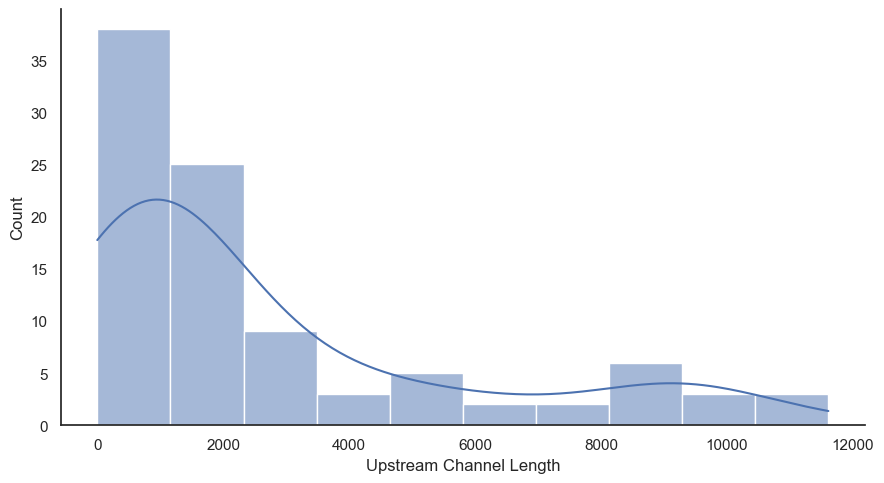

In [31]:
sns.displot(df['Upstream Channel Length'], kde=True, aspect = 1.8);

## Prioritization

Notes and next steps. Looks like I have a lot of NaNs. First I need to go back through and sort those out. Then I can start applying the scoring criteria and adding that to the df. Then output that as a .csv and connect to it in Power BI to start visualizing and exporing.

### Priority Streams Score

- Scores from 0.5 to 9
- Based on WMP subbasin managment strategies and EMP stream prioritization tiers
- Scores can be found in `StreamSubasinTierAndManagementStrategies.xlsx` and thus are already in `df`

### Barrier Status Score

- Scores from 1 to 10  
- Based on the assessed barrier status
   - Full barrier = 10
   - 2/3 partial barrier = 5
   - Unknown barrier = 5
   - 1/3 partial barrier = 1

In [32]:
df['Barrier Class'].unique().tolist()

['Full Barrier', 'Unknown Barrier', 'Partial Barrier']

In [33]:
df['Fish Passability'].unique().tolist()

['0', 'Unknown', '67', '33']

In [34]:
# Assign Barrier Status Score

# Define scoring logic
mapping = {
    '0': 10,         # Full barrier
    'Unknown': 5,    # Status unknown; treat like a 2/3 barrier
    '33': 5,         # 2/3 partial barrier
    '67': 1          # 1/3 partial barrier
}

df['Barrier Status Score'] = (
    df['Fish Passability']
    .map(mapping)
    .astype('float')
)

df.head()

,FACILITYID,WDFW Site ID,Barrier Site ID,Barrier Class,Fish Passability,Subbasin,Longitude,Latitude,Stream,SEGMENTID,Stream Type,Subbasin Management Strategy,EMP Stream Tier,Subbasin Priority Score,Structure Type,Upstream Channel Length,# Upstream Barriers,Upstream Full Barrier,Upstream Partial Barrier,Upstream No Barrier,Upstream Natural Barrier,Upstream Unknown Barrier,Upstream Barriers,# Downstream Barriers,Downstream Full Barrier,Downstream Partial Barrier,Downstream No Barrier,Downstream Natural Barrier,Downstream Unknown Barrier,Downstream Barriers,Barrier Status Score
1,539989,996964,996964,Full Barrier,0,South Sammamish Area,-122.112194,47.571904,Sammamish Trib 0161,94_12,F,Improve/Sustain,<NA>,0.75,Culvert,603.610419,1,1,0,0,0,0,996479 (Full Barrier),2,1,0,0,0,1,996969 (Full Barrier) -> 922238 (Unknown Barrier),10.0
2,340855,922415,922415,Unknown Barrier,Unknown,Kelsey Creek,-122.137164,47.602446,Kelsey Creek,76_13,F,Improve,Tier 1,6.00,Culvert,74.375453,1,1,0,0,0,0,922423 (Full Barrier),18,3,3,7,0,5,922416 (No Barrier) -> 922408 (Full Barrier) -...,5.0
3,340862,922415,922415,Unknown Barrier,Unknown,Kelsey Creek,-122.137135,47.602461,Kelsey Creek,76_13,F,Improve,Tier 1,6.00,Culvert,74.375453,1,1,0,0,0,0,922423 (Full Barrier),18,3,3,7,0,5,922416 (No Barrier) -> 922408 (Full Barrier) -...,5.0
4,340870,922415,922415,Unknown Barrier,Unknown,Kelsey Creek,-122.137145,47.602450,Kelsey Creek,76_13,F,Improve,Tier 1,6.00,Culvert,74.375453,1,1,0,0,0,0,922423 (Full Barrier),18,3,3,7,0,5,922416 (No Barrier) -> 922408 (Full Barrier) -...,5.0
11,360985,930616,930616,Partial Barrier,67,West Tributary,-122.167504,47.617244,West Tributary,80_03,F,Improve,Tier 2,4.00,Culvert,9144.032696,6,0,3,0,0,3,930615 (Partial Barrier) -> 930614 (Partial Ba...,10,1,1,7,0,1,930617 (No Barrier) -> 930618 (No Barrier) -> ...,1.0


### Downstream Barrier Number Score

- Scale of 1 - 10
- Min/max standardized from current values. This means that in the future as those values shift so will the score. But because all culverts are scored simultaneously and don't retain their scores that's not a problem.
   - **Correction** I am going to log base 2 scale so that few downstream barriers get a disproportionaltely high score compared to many downstream barriers. ie I want the difference between 0 and 1 downstream barrier to weigh more than the difference between 17 and 18 dowstream barriers.
- Downstream barriers are tallied/scored as:
   - Full barriers get 3 points
   - Partial and unknown barriers get 1 point
- Sum those scores up and then invert so that lots of downstream barriers yields a low prioritization score

In [35]:
# Calc DS barrier raw score
df['DS Barrier Raw Score'] = df['Downstream Full Barrier']*3 + df['Downstream Partial Barrier'] + df['Downstream Unknown Barrier']
df.head()

,FACILITYID,WDFW Site ID,Barrier Site ID,Barrier Class,Fish Passability,Subbasin,Longitude,Latitude,Stream,SEGMENTID,Stream Type,Subbasin Management Strategy,EMP Stream Tier,Subbasin Priority Score,Structure Type,Upstream Channel Length,# Upstream Barriers,Upstream Full Barrier,Upstream Partial Barrier,Upstream No Barrier,Upstream Natural Barrier,Upstream Unknown Barrier,Upstream Barriers,# Downstream Barriers,Downstream Full Barrier,Downstream Partial Barrier,Downstream No Barrier,Downstream Natural Barrier,Downstream Unknown Barrier,Downstream Barriers,Barrier Status Score,DS Barrier Raw Score
1,539989,996964,996964,Full Barrier,0,South Sammamish Area,-122.112194,47.571904,Sammamish Trib 0161,94_12,F,Improve/Sustain,<NA>,0.75,Culvert,603.610419,1,1,0,0,0,0,996479 (Full Barrier),2,1,0,0,0,1,996969 (Full Barrier) -> 922238 (Unknown Barrier),10.0,4
2,340855,922415,922415,Unknown Barrier,Unknown,Kelsey Creek,-122.137164,47.602446,Kelsey Creek,76_13,F,Improve,Tier 1,6.00,Culvert,74.375453,1,1,0,0,0,0,922423 (Full Barrier),18,3,3,7,0,5,922416 (No Barrier) -> 922408 (Full Barrier) -...,5.0,17
3,340862,922415,922415,Unknown Barrier,Unknown,Kelsey Creek,-122.137135,47.602461,Kelsey Creek,76_13,F,Improve,Tier 1,6.00,Culvert,74.375453,1,1,0,0,0,0,922423 (Full Barrier),18,3,3,7,0,5,922416 (No Barrier) -> 922408 (Full Barrier) -...,5.0,17
4,340870,922415,922415,Unknown Barrier,Unknown,Kelsey Creek,-122.137145,47.602450,Kelsey Creek,76_13,F,Improve,Tier 1,6.00,Culvert,74.375453,1,1,0,0,0,0,922423 (Full Barrier),18,3,3,7,0,5,922416 (No Barrier) -> 922408 (Full Barrier) -...,5.0,17
11,360985,930616,930616,Partial Barrier,67,West Tributary,-122.167504,47.617244,West Tributary,80_03,F,Improve,Tier 2,4.00,Culvert,9144.032696,6,0,3,0,0,3,930615 (Partial Barrier) -> 930614 (Partial Ba...,10,1,1,7,0,1,930617 (No Barrier) -> 930618 (No Barrier) -> ...,1.0,5


In [36]:
# Log base 2 scale so that smaller numbers of DS barriers have a wider score spread than larger numbers
logscale = np.log2(1+df['DS Barrier Raw Score'])
max(logscale)

5.20945336562895

In [37]:
# Scale and invert the DS barrier score

# Log base 2 scale so that smaller numbers of DS barriers have a wider score spread than larger numbers
logscale = np.log2(1+df['DS Barrier Raw Score'])

# Min/max scale
#scaled = (df['DS Barrier Raw Score'] - min(df['DS Barrier Raw Score']))/(max(df['DS Barrier Raw Score']) - min(df['DS Barrier Raw Score']))
scaled = (logscale - min(logscale))/(max(logscale) - min(logscale))

# Invert so lots of DS barriers get a score of 1 and no DS barriers get a 10
df['Downstream Barrier Score'] = 10 - scaled * 9

df.head()

,FACILITYID,WDFW Site ID,Barrier Site ID,Barrier Class,Fish Passability,Subbasin,Longitude,Latitude,Stream,SEGMENTID,Stream Type,Subbasin Management Strategy,EMP Stream Tier,Subbasin Priority Score,Structure Type,Upstream Channel Length,# Upstream Barriers,Upstream Full Barrier,Upstream Partial Barrier,Upstream No Barrier,Upstream Natural Barrier,Upstream Unknown Barrier,Upstream Barriers,# Downstream Barriers,Downstream Full Barrier,Downstream Partial Barrier,Downstream No Barrier,Downstream Natural Barrier,Downstream Unknown Barrier,Downstream Barriers,Barrier Status Score,DS Barrier Raw Score,Downstream Barrier Score
1,539989,996964,996964,Full Barrier,0,South Sammamish Area,-122.112194,47.571904,Sammamish Trib 0161,94_12,F,Improve/Sustain,<NA>,0.75,Culvert,603.610419,1,1,0,0,0,0,996479 (Full Barrier),2,1,0,0,0,1,996969 (Full Barrier) -> 922238 (Unknown Barrier),10.0,4,5.988571
2,340855,922415,922415,Unknown Barrier,Unknown,Kelsey Creek,-122.137164,47.602446,Kelsey Creek,76_13,F,Improve,Tier 1,6.00,Culvert,74.375453,1,1,0,0,0,0,922423 (Full Barrier),18,3,3,7,0,5,922416 (No Barrier) -> 922408 (Full Barrier) -...,5.0,17,2.795919
3,340862,922415,922415,Unknown Barrier,Unknown,Kelsey Creek,-122.137135,47.602461,Kelsey Creek,76_13,F,Improve,Tier 1,6.00,Culvert,74.375453,1,1,0,0,0,0,922423 (Full Barrier),18,3,3,7,0,5,922416 (No Barrier) -> 922408 (Full Barrier) -...,5.0,17,2.795919
4,340870,922415,922415,Unknown Barrier,Unknown,Kelsey Creek,-122.137145,47.602450,Kelsey Creek,76_13,F,Improve,Tier 1,6.00,Culvert,74.375453,1,1,0,0,0,0,922423 (Full Barrier),18,3,3,7,0,5,922416 (No Barrier) -> 922408 (Full Barrier) -...,5.0,17,2.795919
11,360985,930616,930616,Partial Barrier,67,West Tributary,-122.167504,47.617244,West Tributary,80_03,F,Improve,Tier 2,4.00,Culvert,9144.032696,6,0,3,0,0,3,930615 (Partial Barrier) -> 930614 (Partial Ba...,10,1,1,7,0,1,930617 (No Barrier) -> 930618 (No Barrier) -> ...,1.0,5,5.534145


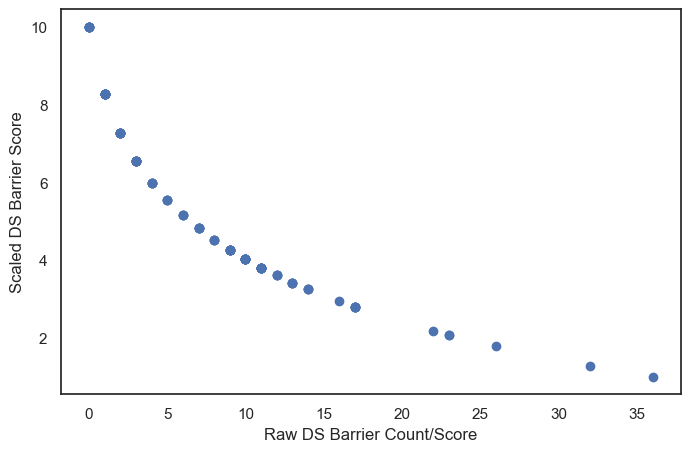

In [38]:
plt.scatter(df['DS Barrier Raw Score'], df['Downstream Barrier Score'])
plt.xlabel("Raw DS Barrier Count/Score")
plt.ylabel("Scaled DS Barrier Score");

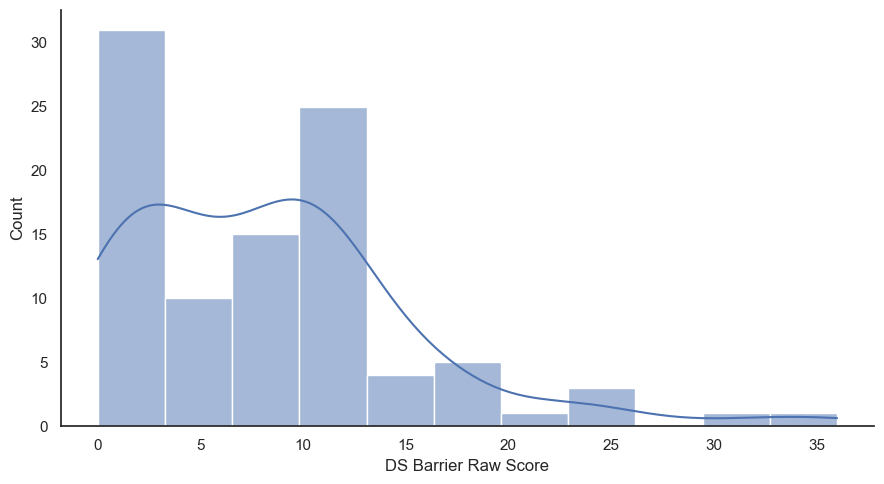

In [39]:
# Let's see what that distribution looks like
sns.displot(df['DS Barrier Raw Score'], kde=True, aspect = 1.8);

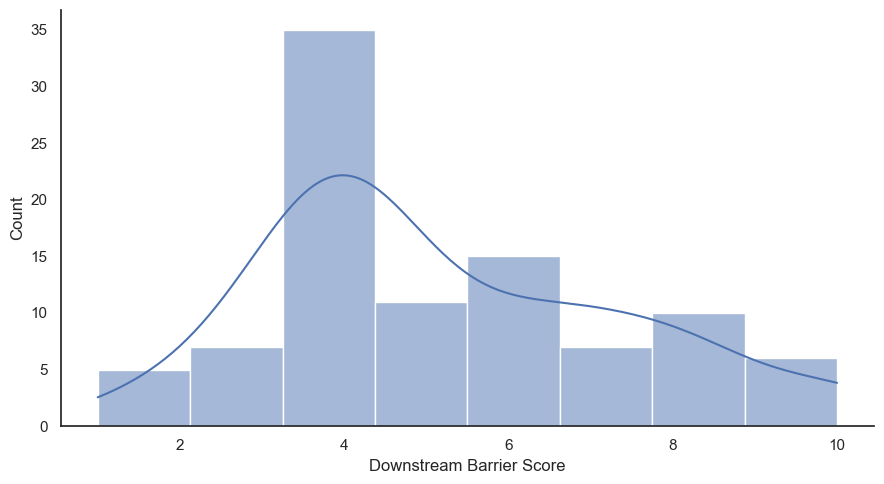

In [40]:
# Let's see what that distribution looks like
sns.displot(df['Downstream Barrier Score'], kde=True, aspect = 1.8);

As one might expect from log transforming the data, it's normalized the distribution.

### Upstream Habitat Score

- Scale 1-10
- Computed as the length of stream channel to the end of the stream or next complete barrier, scaled by the presence of partial or unknown barriers
   - At present, I am multiplying by .75 for each partial barrier. Note that the `# Upstream Barrier` field includes the final full barrier (if present) so must be removed from the calculation.
- Min/max standardized based on present values

In [53]:
# Determine status of next upstream barrier
# Extract the text between the first parentheses
#df['Upstream Barrier Status'] = df['Upstream Barriers'].str.extract(r'\(([^)]+)\)')
#df.head(10)

# this isn't actually needed

In [42]:
# Calculate the raw upstream barrier score
df['US Barrier Raw Score'] = df['Upstream Channel Length'] * 0.75**(df['# Upstream Barriers'] - df['Upstream Full Barrier'])
df.head()

,FACILITYID,WDFW Site ID,Barrier Site ID,Barrier Class,Fish Passability,Subbasin,Longitude,Latitude,Stream,SEGMENTID,Stream Type,Subbasin Management Strategy,EMP Stream Tier,Subbasin Priority Score,Structure Type,Upstream Channel Length,# Upstream Barriers,Upstream Full Barrier,Upstream Partial Barrier,Upstream No Barrier,Upstream Natural Barrier,Upstream Unknown Barrier,Upstream Barriers,# Downstream Barriers,Downstream Full Barrier,Downstream Partial Barrier,Downstream No Barrier,Downstream Natural Barrier,Downstream Unknown Barrier,Downstream Barriers,Barrier Status Score,DS Barrier Raw Score,Downstream Barrier Score,US Barrier Raw Score
1,539989,996964,996964,Full Barrier,0,South Sammamish Area,-122.112194,47.571904,Sammamish Trib 0161,94_12,F,Improve/Sustain,<NA>,0.75,Culvert,603.610419,1,1,0,0,0,0,996479 (Full Barrier),2,1,0,0,0,1,996969 (Full Barrier) -> 922238 (Unknown Barrier),10.0,4,5.988571,603.610419
2,340855,922415,922415,Unknown Barrier,Unknown,Kelsey Creek,-122.137164,47.602446,Kelsey Creek,76_13,F,Improve,Tier 1,6.00,Culvert,74.375453,1,1,0,0,0,0,922423 (Full Barrier),18,3,3,7,0,5,922416 (No Barrier) -> 922408 (Full Barrier) -...,5.0,17,2.795919,74.375453
3,340862,922415,922415,Unknown Barrier,Unknown,Kelsey Creek,-122.137135,47.602461,Kelsey Creek,76_13,F,Improve,Tier 1,6.00,Culvert,74.375453,1,1,0,0,0,0,922423 (Full Barrier),18,3,3,7,0,5,922416 (No Barrier) -> 922408 (Full Barrier) -...,5.0,17,2.795919,74.375453
4,340870,922415,922415,Unknown Barrier,Unknown,Kelsey Creek,-122.137145,47.602450,Kelsey Creek,76_13,F,Improve,Tier 1,6.00,Culvert,74.375453,1,1,0,0,0,0,922423 (Full Barrier),18,3,3,7,0,5,922416 (No Barrier) -> 922408 (Full Barrier) -...,5.0,17,2.795919,74.375453
11,360985,930616,930616,Partial Barrier,67,West Tributary,-122.167504,47.617244,West Tributary,80_03,F,Improve,Tier 2,4.00,Culvert,9144.032696,6,0,3,0,0,3,930615 (Partial Barrier) -> 930614 (Partial Ba...,10,1,1,7,0,1,930617 (No Barrier) -> 930618 (No Barrier) -> ...,1.0,5,5.534145,1627.441366


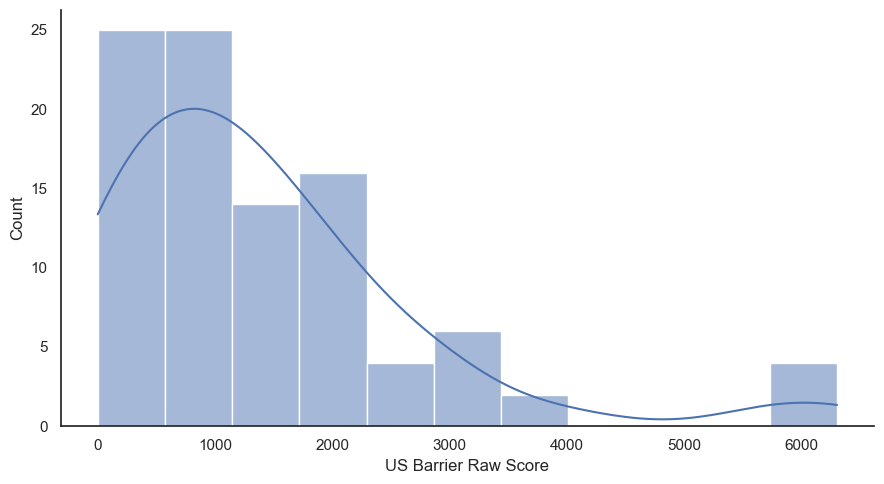

In [43]:
# Let's see what that distribution looks like
sns.displot(df['US Barrier Raw Score'], kde=True, aspect = 1.8);

In [44]:
# Min/max scale with a range of 1 to 10
df['Upstream Barrier Score'] = 1 + 9 * (df['US Barrier Raw Score'] - min(df['US Barrier Raw Score']))/(max(df['US Barrier Raw Score']) - min(df['US Barrier Raw Score']))
df.head()

,FACILITYID,WDFW Site ID,Barrier Site ID,Barrier Class,Fish Passability,Subbasin,Longitude,Latitude,Stream,SEGMENTID,Stream Type,Subbasin Management Strategy,EMP Stream Tier,Subbasin Priority Score,Structure Type,Upstream Channel Length,# Upstream Barriers,Upstream Full Barrier,Upstream Partial Barrier,Upstream No Barrier,Upstream Natural Barrier,Upstream Unknown Barrier,Upstream Barriers,# Downstream Barriers,Downstream Full Barrier,Downstream Partial Barrier,Downstream No Barrier,Downstream Natural Barrier,Downstream Unknown Barrier,Downstream Barriers,Barrier Status Score,DS Barrier Raw Score,Downstream Barrier Score,US Barrier Raw Score,Upstream Barrier Score
1,539989,996964,996964,Full Barrier,0,South Sammamish Area,-122.112194,47.571904,Sammamish Trib 0161,94_12,F,Improve/Sustain,<NA>,0.75,Culvert,603.610419,1,1,0,0,0,0,996479 (Full Barrier),2,1,0,0,0,1,996969 (Full Barrier) -> 922238 (Unknown Barrier),10.0,4,5.988571,603.610419,1.861362
2,340855,922415,922415,Unknown Barrier,Unknown,Kelsey Creek,-122.137164,47.602446,Kelsey Creek,76_13,F,Improve,Tier 1,6.00,Culvert,74.375453,1,1,0,0,0,0,922423 (Full Barrier),18,3,3,7,0,5,922416 (No Barrier) -> 922408 (Full Barrier) -...,5.0,17,2.795919,74.375453,1.106135
3,340862,922415,922415,Unknown Barrier,Unknown,Kelsey Creek,-122.137135,47.602461,Kelsey Creek,76_13,F,Improve,Tier 1,6.00,Culvert,74.375453,1,1,0,0,0,0,922423 (Full Barrier),18,3,3,7,0,5,922416 (No Barrier) -> 922408 (Full Barrier) -...,5.0,17,2.795919,74.375453,1.106135
4,340870,922415,922415,Unknown Barrier,Unknown,Kelsey Creek,-122.137145,47.602450,Kelsey Creek,76_13,F,Improve,Tier 1,6.00,Culvert,74.375453,1,1,0,0,0,0,922423 (Full Barrier),18,3,3,7,0,5,922416 (No Barrier) -> 922408 (Full Barrier) -...,5.0,17,2.795919,74.375453,1.106135
11,360985,930616,930616,Partial Barrier,67,West Tributary,-122.167504,47.617244,West Tributary,80_03,F,Improve,Tier 2,4.00,Culvert,9144.032696,6,0,3,0,0,3,930615 (Partial Barrier) -> 930614 (Partial Ba...,10,1,1,7,0,1,930617 (No Barrier) -> 930618 (No Barrier) -> ...,1.0,5,5.534145,1627.441366,3.322385


**NOTE:** At present, I believe there are issues with the consultant's computed upstream length. I need to look into this more. Once I get that sorted, it would be worthwhile to re-evaluate this scaled score. As it stands, a 22X increase in available habitat is only worth 2 points more. That doesn't seem right. Perhaps this parameter should be worth more than 10 points?

### Natural Barrier Score

- A binary score that essentially creates a step function for the prioritization score so that all barriers upstream of natural barriers are priorized *after* barriers that are not upstream of natural barriers.

In [45]:
# Assign the natural barrier score - 100 if there are no DS natural barriers, otherwise 0

df['Natural Barrier Score'] = np.where(
    df['Downstream Natural Barrier'] == 0, 
    100, 
    0
)

df.head()

,FACILITYID,WDFW Site ID,Barrier Site ID,Barrier Class,Fish Passability,Subbasin,Longitude,Latitude,Stream,SEGMENTID,Stream Type,Subbasin Management Strategy,EMP Stream Tier,Subbasin Priority Score,Structure Type,Upstream Channel Length,# Upstream Barriers,Upstream Full Barrier,Upstream Partial Barrier,Upstream No Barrier,Upstream Natural Barrier,Upstream Unknown Barrier,Upstream Barriers,# Downstream Barriers,Downstream Full Barrier,Downstream Partial Barrier,Downstream No Barrier,Downstream Natural Barrier,Downstream Unknown Barrier,Downstream Barriers,Barrier Status Score,DS Barrier Raw Score,Downstream Barrier Score,US Barrier Raw Score,Upstream Barrier Score,Natural Barrier Score
1,539989,996964,996964,Full Barrier,0,South Sammamish Area,-122.112194,47.571904,Sammamish Trib 0161,94_12,F,Improve/Sustain,<NA>,0.75,Culvert,603.610419,1,1,0,0,0,0,996479 (Full Barrier),2,1,0,0,0,1,996969 (Full Barrier) -> 922238 (Unknown Barrier),10.0,4,5.988571,603.610419,1.861362,100
2,340855,922415,922415,Unknown Barrier,Unknown,Kelsey Creek,-122.137164,47.602446,Kelsey Creek,76_13,F,Improve,Tier 1,6.00,Culvert,74.375453,1,1,0,0,0,0,922423 (Full Barrier),18,3,3,7,0,5,922416 (No Barrier) -> 922408 (Full Barrier) -...,5.0,17,2.795919,74.375453,1.106135,100
3,340862,922415,922415,Unknown Barrier,Unknown,Kelsey Creek,-122.137135,47.602461,Kelsey Creek,76_13,F,Improve,Tier 1,6.00,Culvert,74.375453,1,1,0,0,0,0,922423 (Full Barrier),18,3,3,7,0,5,922416 (No Barrier) -> 922408 (Full Barrier) -...,5.0,17,2.795919,74.375453,1.106135,100
4,340870,922415,922415,Unknown Barrier,Unknown,Kelsey Creek,-122.137145,47.602450,Kelsey Creek,76_13,F,Improve,Tier 1,6.00,Culvert,74.375453,1,1,0,0,0,0,922423 (Full Barrier),18,3,3,7,0,5,922416 (No Barrier) -> 922408 (Full Barrier) -...,5.0,17,2.795919,74.375453,1.106135,100
11,360985,930616,930616,Partial Barrier,67,West Tributary,-122.167504,47.617244,West Tributary,80_03,F,Improve,Tier 2,4.00,Culvert,9144.032696,6,0,3,0,0,3,930615 (Partial Barrier) -> 930614 (Partial Ba...,10,1,1,7,0,1,930617 (No Barrier) -> 930618 (No Barrier) -> ...,1.0,5,5.534145,1627.441366,3.322385,100


### Priority Score

- Ultimately, I think it would be best if the formula to compute the priority score was here for completeness. However, I think I'll take the dataframe over into the Power BI and explore some options - addtitive, multiplicative, etc.

In [48]:
# Write the dataframe to a csv
df.to_csv(r"V:\UtilitiesDeptGIS\ArcGIS\Watershed Planning Team\Environmental Monitoring\Fish Passage Barriers\Fish Passage Barriers\Output\FPB_PrioritizationDataframe.csv",
          index=False, sep=',', header=True)